In [1]:
try:
    import truststore
    truststore.inject_into_ssl()
    print('OK  truststore attivo')
except ImportError:
    print('!!  pip install truststore  (se i download falliscono con errore SSL)')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
from pathlib import Path

try:
    import plotly.graph_objects as go
    import plotly.express as px
    PLOTLY = True
    print('OK  plotly disponibile')
except ImportError:
    PLOTLY = False
    print('!!  pip install plotly  (per la mappa 3D interattiva)')

# --- Trova la ROOT del progetto, cosi' Data/ e Images/ finiscono sempre nel posto
#     giusto sia che il notebook parta dalla root sia dalla cartella Scripts/ ---
ROOT = Path.cwd()
if ROOT.name == 'Scripts':
    ROOT = ROOT.parent          # eseguito da dentro Scripts/ -> sali di un livello
DATA_DIR = ROOT / 'Data'
IMG_DIR  = ROOT / 'Images'
print('Root del progetto:', ROOT)

np.random.seed(42)
plt.rcParams['figure.dpi'] = 110
print('Librerie caricate')

OK  truststore attivo
OK  plotly disponibile
Root del progetto: c:\Users\utente\Pianeti_Stelle
Librerie caricate


---
# PARTE A — Gaia DR3 e la cinematica a 6 dimensioni

Per ogni stella, Gaia misura fino a **6 numeri** che ne fissano posizione e moto nello
spazio (lo *spazio delle fasi* 6D):

| Simbolo | Grandezza | Cosa dà |
|---|---|---|
| `ra`, `dec` | posizione in cielo | 2 angoli |
| `parallax` | parallasse (mas) | **distanza** = 1/parallasse (kpc) |
| `pmra`, `pmdec` | moti propri (mas/yr) | moto **trasversale** in cielo |
| `radial_velocity` | velocità radiale (km/s) | moto **lungo la linea di vista** |

Con questi 6 numeri più la distanza si ricava il **vettore velocità completo** della
stella. Aggiungiamo la **metallicità** `mh_gspphot` = [M/H] (quanto è ricca di elementi
pesanti): è l'impronta chimica che, insieme al moto, distingue le popolazioni stellari.

### A.1 Perché velocità e metallicità insieme tradiscono un'accrezione

- Le stelle **nate nel disco** della Via Lattea **ruotano** ordinatamente attorno al
  centro (~230 km/s) e sono **ricche di metalli** ([M/H] ≈ 0): generazioni di stelle le
  hanno arricchite.
- Le stelle di una **galassia nana accretata** arrivano da fuori: **non ruotano** col
  disco (orbite radiali, "tuffi" verso il centro e ritorno) e sono **povere di metalli**
  ([M/H] ≈ −1.3), perché venivano da una galassia piccola e poco evoluta.

Trova le stelle *povere di metalli che non ruotano*, e avrai trovato un relitto.

### A.2 Dai 6 numeri grezzi alle velocità galattiche (U, V, W)

Questa è la trasformazione centrale del notebook. Convertiamo (ra, dec, parallasse, moti
propri, velocità radiale) nelle tre componenti della velocità nel sistema **galattico**:

- **U** — verso il centro galattico
- **V** — nel verso della rotazione del disco
- **W** — verso il polo nord galattico

Il metodo è quello classico di **Johnson & Soderblom (1987)**: si ruota il vettore
velocità dal sistema equatoriale a quello galattico con una matrice fissa, poi si corregge
per il moto del Sole. Lo implementiamo da zero — nessuna scatola nera.

In [2]:
# Matrice di rotazione equatoriale (J2000) -> galattico (Johnson & Soderblom 1987)
A_G = np.array([
    [-0.0548755604, -0.8734370902, -0.4838350155],
    [ 0.4941094279, -0.4448296300,  0.7469822445],
    [-0.8676661490, -0.1980763734,  0.4559837762]])

K_AU = 4.740470446          # (km/s) per (mas/yr) per kpc

# Moto del Sole rispetto al Local Standard of Rest (Schoenrich+ 2010) e rotazione galattica
U_SUN, V_SUN, W_SUN = 11.1, 12.24, 7.25    # km/s
V_LSR = 232.8                               # km/s, velocita' di rotazione al raggio solare
R_SUN = 8.178                               # kpc, distanza Sole-centro galattico (GRAVITY 2019)

def compute_kinematics(df):
    """Da (ra,dec,parallax,pmra,pmdec,rv) calcola posizioni (X,Y,Z) e velocita' (U,V,W)
    galattiche, piu' il momento angolare Lz. Tutto vettorializzato."""
    d   = 1.0 / df['parallax'].values                 # kpc
    ra  = np.radians(df['ra'].values)
    dec = np.radians(df['dec'].values)
    pmra, pmdec = df['pmra'].values, df['pmdec'].values
    rv  = df['radial_velocity'].values

    # --- posizione: versore equatoriale -> galattico -> (l,b) -> (X,Y,Z) eliocentrici ---
    x_eq = np.vstack([np.cos(dec)*np.cos(ra), np.cos(dec)*np.sin(ra), np.sin(dec)])
    x_g = A_G @ x_eq
    l = np.arctan2(x_g[1], x_g[0]); b = np.arcsin(np.clip(x_g[2], -1, 1))
    X = d*np.cos(b)*np.cos(l); Y = d*np.cos(b)*np.sin(l); Z = d*np.sin(b)

    # --- velocita': componenti equatoriali cartesiane -> galattiche ---
    v_ra  = K_AU * pmra  * d      # km/s, moto proprio in AR proiettato
    v_dec = K_AU * pmdec * d      # km/s, moto proprio in Dec proiettato
    cr, sr = np.cos(ra), np.sin(ra)
    cd, sd = np.cos(dec), np.sin(dec)
    vx = rv*cd*cr - v_ra*sr - v_dec*sd*cr
    vy = rv*cd*sr + v_ra*cr - v_dec*sd*sr
    vz = rv*sd            + v_dec*cd
    UVW = A_G @ np.vstack([vx, vy, vz])

    U = UVW[0] + U_SUN                 # verso il centro
    V = UVW[1] + V_SUN                 # verso la rotazione (ancora rispetto all'LSR)
    W = UVW[2] + W_SUN                 # verso il polo nord
    V_rot = V + V_LSR                  # velocita' di rotazione galattica assoluta

    out = df.copy()
    out['X'], out['Y'], out['Z'] = X, Y, Z
    out['U'], out['V'], out['W'] = U, V, W
    out['V_rot'] = V_rot
    out['v_tot'] = np.sqrt(U**2 + V**2 + W**2)     # velocita' rispetto all'LSR
    out['Lz'] = R_SUN * V_rot                        # momento angolare (approx locale)
    return out

print('Funzioni di cinematica pronte (Johnson & Soderblom 1987).')
print('V_LSR = %.1f km/s | R_sun = %.3f kpc' % (V_LSR, R_SUN))

Funzioni di cinematica pronte (Johnson & Soderblom 1987).
V_LSR = 232.8 km/s | R_sun = 8.178 kpc


---
# PARTE B — Scarichiamo le stelle reali da Gaia DR3

Interroghiamo l'**archivio Gaia dell'ESA** via TAP (ADQL, come il NASA Archive del 018 e
VizieR del 019). Selezioniamo stelle con:

- cinematica **6D completa** (parallasse + moti propri + velocità radiale)
- **metallicità** misurata (`mh_gspphot`)
- buona qualità (`parallax_over_error > 5`, `ruwe < 1.4` = astrometria affidabile)
- a distanze **0.2–2 kpc** (dove l'alone locale è ben campionato)

> 💾 **Cache locale** (come nei notebook precedenti). Il download (~200k stelle) richiede
> un paio di minuti e la connessione. Lo salviamo in `Data/`: le esecuzioni successive
> leggono da disco, offline e riproducibili.

In [3]:
GAIA_TAP = "https://gea.esac.esa.int/tap-server/tap/sync"
UA = {'User-Agent': 'Mozilla/5.0 (notebook didattico)'}
CACHE = DATA_DIR / 'gaia_dr3_halo_sample.csv'

QUERY = """
SELECT TOP 200000 source_id, ra, dec, parallax, parallax_over_error,
       pmra, pmdec, radial_velocity, mh_gspphot, teff_gspphot,
       phot_g_mean_mag, bp_rp
FROM gaiadr3.gaia_source
WHERE parallax BETWEEN 0.5 AND 5
  AND parallax_over_error > 5
  AND radial_velocity IS NOT NULL
  AND mh_gspphot IS NOT NULL
  AND ruwe < 1.4
"""

def download_gaia():
    r = requests.post(GAIA_TAP, headers=UA, timeout=600,
                      data={'REQUEST': 'doQuery', 'LANG': 'ADQL',
                            'FORMAT': 'json', 'QUERY': QUERY})
    if r.status_code != 200:
        raise RuntimeError('Gaia HTTP %s: %s' % (r.status_code, r.text[:300]))
    j = r.json()
    return pd.DataFrame(j['data'], columns=[c['name'] for c in j['metadata']])

if CACHE.exists():
    raw = pd.read_csv(CACHE)
    print('Caricato da cache locale: %s' % CACHE)
else:
    print('Scarico da Gaia DR3 (puo\' richiedere 1-2 minuti)...')
    raw = download_gaia()
    CACHE.parent.mkdir(exist_ok=True)
    raw.to_csv(CACHE, index=False)
    print('Scaricato e salvato in %s' % CACHE)

for c in raw.columns:
    raw[c] = pd.to_numeric(raw[c], errors='coerce')
raw = raw.dropna(subset=['ra','dec','parallax','pmra','pmdec','radial_velocity','mh_gspphot'])
print('Stelle nel campione: %d' % len(raw))

Caricato da cache locale: c:\Users\utente\Pianeti_Stelle\Data\gaia_dr3_halo_sample.csv
Stelle nel campione: 200000


In [4]:
# Applichiamo la cinematica 6D a tutte le stelle
stars = compute_kinematics(raw)

print('Cinematica calcolata per %d stelle.' % len(stars))
print()
print('  distanze  : %.2f - %.2f kpc' % ((1/stars.parallax).min(), (1/stars.parallax).max()))
print('  [M/H]     : %+.2f - %+.2f' % (stars.mh_gspphot.min(), stars.mh_gspphot.max()))
print('  V_rot     : %.0f - %.0f km/s' % (stars.V_rot.min(), stars.V_rot.max()))
print()
display(stars[['source_id','parallax','mh_gspphot','U','V_rot','W','v_tot','Lz']].head())

Cinematica calcolata per 200000 stelle.

  distanze  : 0.20 - 2.00 kpc
  [M/H]     : -4.14 - +0.80
  V_rot     : -301 - 552 km/s



,source_id,parallax,mh_gspphot,U,V_rot,W,v_tot,Lz
0,137353402019695744,1.690558,0.0983,11.871473,204.814943,8.784619,31.642769,1674.976605
1,137354742049485312,1.197509,-0.2519,8.922291,261.842791,3.706532,30.607668,2141.350343
2,138757925045155584,2.774807,-0.4366,-12.008914,224.266923,18.834198,23.911387,1834.054896
3,138763250804593664,1.266621,-0.0069,5.288377,261.500797,-9.569117,30.712712,2138.553521
4,138845297564292480,0.847202,-0.1242,37.001253,186.781473,-0.177014,59.049376,1527.498886


---
# PARTE C — Il diagramma di Toomre: disco vs alone

Il primo passo dell'archeologia galattica è **separare le popolazioni per cinematica**,
senza ancora guardare la chimica. Lo strumento classico è il **diagramma di Toomre**:

$$\text{asse x} = V \;(\text{rotazione}), \qquad
\text{asse y} = \sqrt{U^2 + W^2} \;(\text{moto non-rotazionale})$$

- Le stelle del **disco** si affollano attorno a V ≈ 232 km/s (ruotano) con poco moto
  verticale/radiale → stanno **in basso a destra**.
- Le stelle dell'**alone** hanno V ≈ 0 (non ruotano) e grande moto casuale → formano un
  **arco in alto**, staccato dal disco.

Le circonferenze di velocità totale costante rispetto all'LSR aiutano a leggere il grafico.

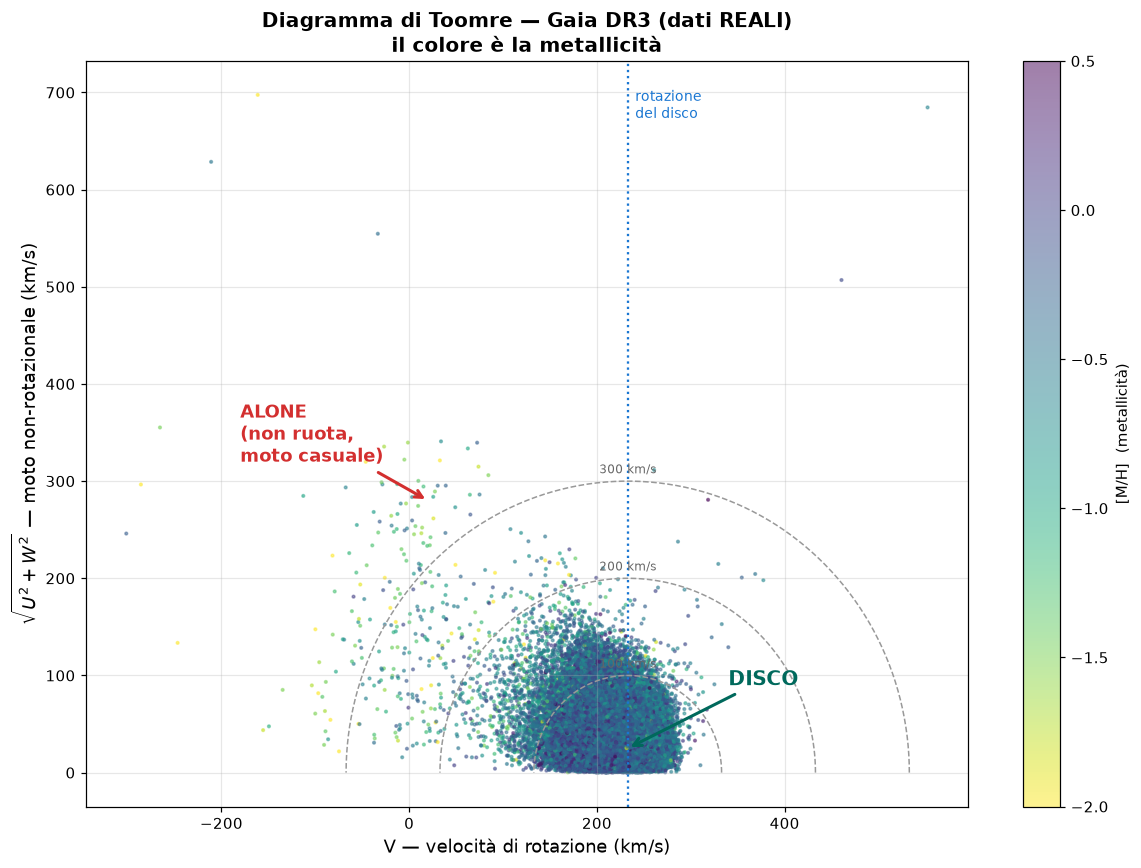

Nota il colore: l'arco dell'alone (in alto) e' sistematicamente PIU' BLU
(metal-poor) del disco (in basso, giallo/verde = metal-rich).
Cinematica e chimica raccontano la STESSA storia.


In [5]:
U = stars.U.values; W = stars.W.values; V_rot = stars.V_rot.values
toomre_y = np.sqrt(U**2 + W**2)
v_tot = stars.v_tot.values

fig, ax = plt.subplots(figsize=(11, 8))
sc = ax.scatter(V_rot, toomre_y, s=3, c=stars.mh_gspphot, cmap='viridis_r',
                vmin=-2, vmax=0.5, alpha=0.5)
cb = plt.colorbar(sc, label='[M/H]  (metallicità)')

# circonferenze di v_tot costante (rispetto all'LSR, centrate su V=V_LSR)
for vt in [100, 200, 300]:
    th = np.linspace(0, np.pi, 100)
    ax.plot(V_LSR + vt*np.cos(th), vt*np.sin(th), '--', color='0.6', lw=1)
    ax.text(V_LSR, vt+8, '%d km/s' % vt, ha='center', fontsize=8, color='0.4')

ax.axvline(V_LSR, color='#1976D2', ls=':', lw=1.5)
ax.text(V_LSR+8, ax.get_ylim()[1]*0.92, 'rotazione\ndel disco', color='#1976D2', fontsize=9)
ax.annotate('ALONE\n(non ruota,\nmoto casuale)', xy=(20, 280), xytext=(-180, 320),
            fontsize=12, color='#D32F2F', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#D32F2F', lw=2))
ax.annotate('DISCO', xy=(V_LSR, 25), xytext=(340, 90), fontsize=13, color='#00695C',
            fontweight='bold', arrowprops=dict(arrowstyle='->', color='#00695C', lw=2))

ax.set_xlabel('V — velocità di rotazione (km/s)', fontsize=12)
ax.set_ylabel(r'$\sqrt{U^2 + W^2}$ — moto non-rotazionale (km/s)', fontsize=12)
ax.set_title('Diagramma di Toomre — Gaia DR3 (dati REALI)\nil colore è la metallicità',
             fontsize=13, fontweight='bold')
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print('Nota il colore: l\'arco dell\'alone (in alto) e\' sistematicamente PIU\' BLU')
print('(metal-poor) del disco (in basso, giallo/verde = metal-rich).')
print('Cinematica e chimica raccontano la STESSA storia.')

---
# PARTE D — Dove Enceladus emerge: il piano [M/H]–Lz

Ora la diagnostica decisiva. Mettiamo su due assi:

- **x = Lz** (momento angolare) — quanto una stella "gira" attorno al centro galattico.
  Lz grande e positivo = ruota col disco; Lz ≈ 0 = non ruota (orbita radiale).
- **y = [M/H]** (metallicità) — l'impronta chimica.

In questo piano le popolazioni si separano nettamente:

| Popolazione | Lz | [M/H] | Origine |
|---|---|---|---|
| **Disco** | grande, positivo | ≈ 0 | nata nella Via Lattea |
| **Gaia-Enceladus** | ≈ 0 | ≈ −1.3 | galassia nana accretata |

Selezioniamo **l'alone** (stelle cinematicamente calde) e guardiamo dove si accumulano.

Alone (v_tot > 180 km/s): 454 stelle
Disco (v_tot < 60 km/s) : 162846 stelle

Metallicita' mediana:
  disco : [M/H] = -0.30
  alone : [M/H] = -0.75


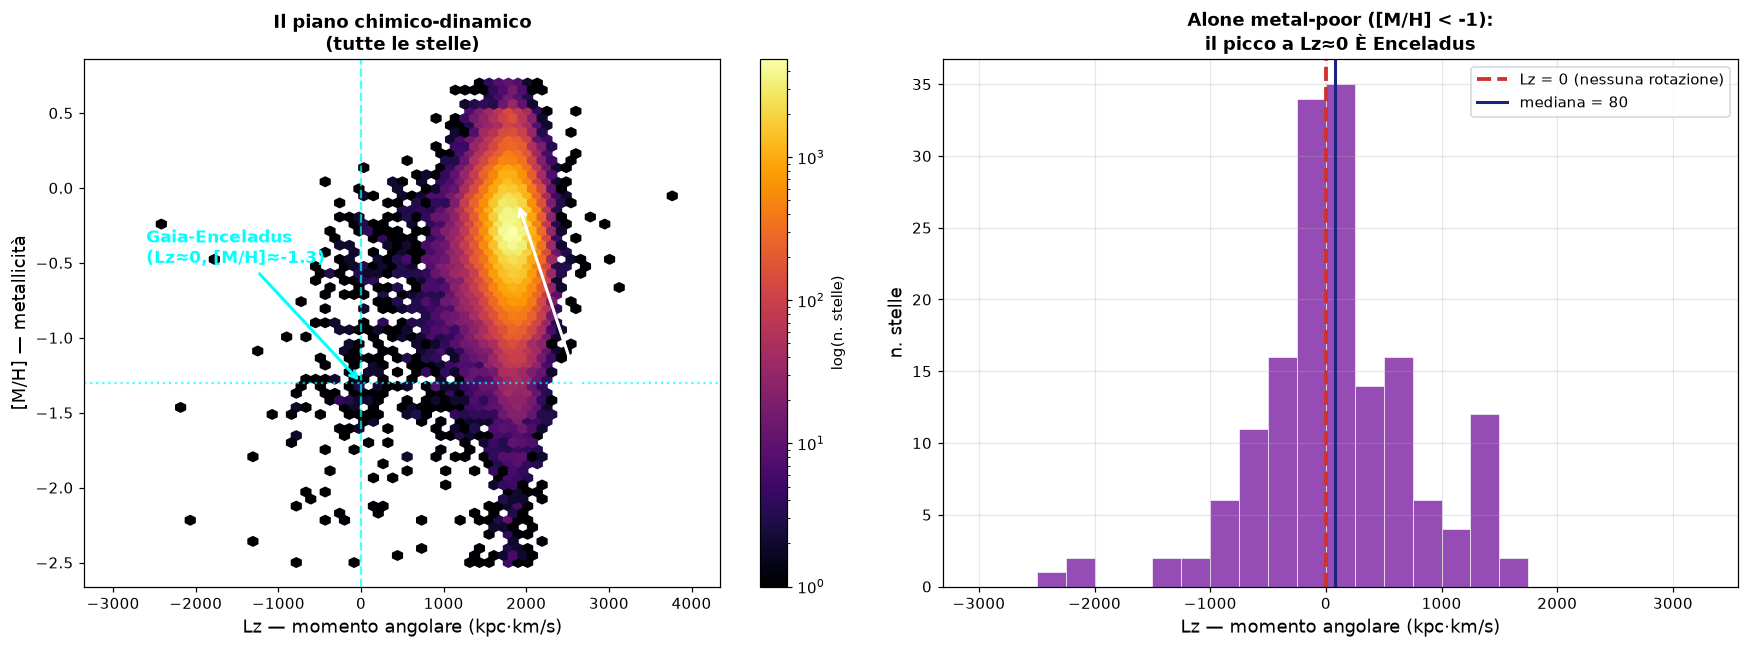

In [6]:
# L'alone: stelle con alta velocita' rispetto all'LSR
halo = stars[stars.v_tot > 180].copy()
disk = stars[stars.v_tot < 60].copy()
print('Alone (v_tot > 180 km/s): %d stelle' % len(halo))
print('Disco (v_tot < 60 km/s) : %d stelle' % len(disk))
print()
print('Metallicita\' mediana:')
print('  disco : [M/H] = %+.2f' % disk.mh_gspphot.median())
print('  alone : [M/H] = %+.2f' % halo.mh_gspphot.median())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- pannello 1: il piano [M/H] vs Lz per tutte le stelle ---
ax = axes[0]
h = ax.hexbin(stars.Lz, stars.mh_gspphot, gridsize=60, cmap='inferno', bins='log',
              extent=[-3000, 4000, -2.5, 0.7])
plt.colorbar(h, ax=ax, label='log(n. stelle)')
ax.axvline(0, color='cyan', ls='--', lw=1.5, alpha=0.7)
ax.axhline(-1.3, color='cyan', ls=':', lw=1.5, alpha=0.7)
ax.annotate('Gaia-Enceladus\n(Lz≈0, [M/H]≈-1.3)', xy=(0, -1.3), xytext=(-2600, -0.5),
            color='cyan', fontsize=11, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='cyan', lw=2))
ax.annotate('DISCO', xy=(1900, -0.1), xytext=(2400, -1.6), color='white', fontsize=12,
            fontweight='bold', arrowprops=dict(arrowstyle='->', color='white', lw=2))
ax.set_xlabel('Lz — momento angolare (kpc·km/s)', fontsize=12)
ax.set_ylabel('[M/H] — metallicità', fontsize=12)
ax.set_title('Il piano chimico-dinamico\n(tutte le stelle)', fontsize=12, fontweight='bold')

# --- pannello 2: istogramma di Lz per l'alone metal-poor ---
ax = axes[1]
mp = halo[halo.mh_gspphot < -1.0]
ax.hist(mp.Lz, bins=np.arange(-3000, 3500, 250), color='#7B1FA2', alpha=0.8,
        edgecolor='white', lw=0.5)
ax.axvline(0, color='#D32F2F', ls='--', lw=2.5, label='Lz = 0 (nessuna rotazione)')
ax.axvline(mp.Lz.median(), color='#1A237E', ls='-', lw=2,
           label='mediana = %.0f' % mp.Lz.median())
ax.set_xlabel('Lz — momento angolare (kpc·km/s)', fontsize=12)
ax.set_ylabel('n. stelle', fontsize=12)
ax.set_title('Alone metal-poor ([M/H] < -1):\nil picco a Lz≈0 È Enceladus', fontsize=12,
             fontweight='bold')
ax.legend(fontsize=10); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### D.1 Selezioniamo Gaia-Enceladus e misuriamone le proprietà

In [7]:
# Criteri (dai paper Helmi 2018 / Belokurov 2018), applicati ai NOSTRI dati:
#   alone cinematico (v_tot alta) + metal-poor + poco momento angolare (orbite radiali)
enceladus = stars[(stars.v_tot > 180) &
                  (stars.mh_gspphot > -2.2) & (stars.mh_gspphot < -0.9) &
                  (np.abs(stars.Lz) < 500)].copy()

print('=' * 60)
print('GAIA-ENCELADUS — proprietà misurate dai dati')
print('=' * 60)
print('  stelle selezionate : %d' % len(enceladus))
print('  [M/H] mediana      : %+.2f    (letteratura: ~ -1.3)' % enceladus.mh_gspphot.median())
print('  Lz mediano         : %+.0f kpc·km/s  (~0 = non ruota)' % enceladus.Lz.median())
print('  V_rot mediana      : %+.0f km/s   (disco: ~%d)' % (enceladus.V_rot.median(), int(V_LSR)))
print('  v_tot mediana      : %.0f km/s   (cinematicamente calda)' % enceladus.v_tot.median())
print()
print('  CONFRONTO col disco (stesse quantita\'):')
print('    disco  : [M/H]=%+.2f, V_rot=%+.0f, v_tot=%.0f'
      % (disk.mh_gspphot.median(), disk.V_rot.median(), disk.v_tot.median()))
print('    Encel. : [M/H]=%+.2f, V_rot=%+.0f, v_tot=%.0f'
      % (enceladus.mh_gspphot.median(), enceladus.V_rot.median(), enceladus.v_tot.median()))
print()
print('  -> Queste stelle NON ruotano col disco e sono POVERE di metalli.')
print('     Non sono nate qui: sono il relitto di una galassia nana accretata.')

GAIA-ENCELADUS — proprietà misurate dai dati
  stelle selezionate : 107
  [M/H] mediana      : -1.33    (letteratura: ~ -1.3)
  Lz mediano         : +2 kpc·km/s  (~0 = non ruota)
  V_rot mediana      : +0 km/s   (disco: ~232)
  v_tot mediana      : 284 km/s   (cinematicamente calda)

  CONFRONTO col disco (stesse quantita'):
    disco  : [M/H]=-0.30, V_rot=+224, v_tot=32
    Encel. : [M/H]=-1.33, V_rot=+0, v_tot=284

  -> Queste stelle NON ruotano col disco e sono POVERE di metalli.
     Non sono nate qui: sono il relitto di una galassia nana accretata.


---
# PARTE E — Quando avvenne la fusione?

Non possiamo datare la fusione con la sola cinematica locale (servirebbero le età stellari
da isocroni o astersismologia, non incluse in questo campione). Ma possiamo **ragionare**
sui vincoli che i dati forniscono, ed è istruttivo vedere *come* si arriva a "~8–10 Gyr".

### Gli indizi

1. **La metallicità dice la massa della nana.** [M/H] ≈ −1.3 e la *relazione
   massa-metallicità* delle galassie collocano Enceladus a ~10⁹ masse solari di stelle:
   una nana massiccia, paragonabile alla Piccola Nube di Magellano.

2. **L'orbita radiale (Lz ≈ 0) dice che il sistema è "rilassato".** Dopo una fusione, le
   stelle accretate impiegano tempo a mescolarsi uniformemente nell'alone. Che siano già
   ben mescolate e prive di sottostrutture spaziali coerenti implica **molti** giri
   orbitali → **molti** Gyr.

3. **Il "ginocchio" chimico [α/Fe] (dai paper).** Il rapporto α/ferro delle stelle di
   Enceladus mostra un calo a bassa metallicità: segna il momento in cui le supernovae di
   tipo Ia iniziano a contribuire, il che vincola la durata della formazione stellare
   della nana e, con i modelli, l'epoca della fusione.

Combinando questi vincoli con i modelli di formazione, i lavori di Helmi et al. 2018 e
successivi datano la fusione a **8–10 miliardi di anni fa** — quando la Via Lattea aveva
meno di metà della sua età attuale.

Cio' che i NOSTRI dati vincolano direttamente:
  dispersione di velocita' (km/s):
    sigma_U (radiale)  = 165
    sigma_V (rotaz.)   = 30
    sigma_W (verticale)= 73

  anisotropia beta = 0.88
  (beta -> 1 = orbite molto RADIALI: la firma della "Sausage")

  Questa forte anisotropia radiale e' esattamente cio' che
  Belokurov et al. 2018 chiamarono "Gaia Sausage": un sistema
  dominato da orbite che si tuffano verso il centro e tornano.

  L'eta' della fusione (8-10 Gyr) richiede pero' le ETA' stellari,
  che questo campione non contiene: e' un vincolo di LETTERATURA
  (Helmi+ 2018), non una nostra misura. Lo diciamo onestamente.


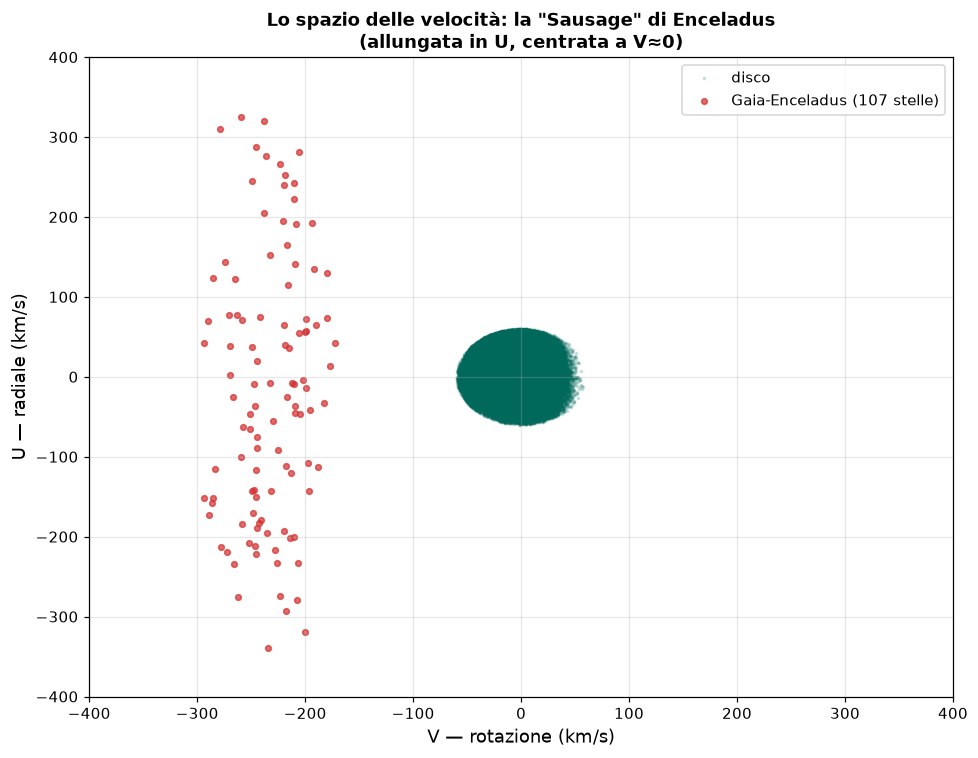

In [8]:
# Cosa possiamo misurare NOI dai dati (senza le eta' stellari):
# la dispersione di velocita' dell'alone, che indica un sistema dinamicamente rilassato.
sigma_U = enceladus.U.std()
sigma_V = enceladus.V.std()
sigma_W = enceladus.W.std()
anisotropy = 1 - (sigma_V**2 + sigma_W**2) / (2 * sigma_U**2)   # parametro beta

print('Cio\' che i NOSTRI dati vincolano direttamente:')
print('=' * 56)
print('  dispersione di velocita\' (km/s):')
print('    sigma_U (radiale)  = %.0f' % sigma_U)
print('    sigma_V (rotaz.)   = %.0f' % sigma_V)
print('    sigma_W (verticale)= %.0f' % sigma_W)
print()
print('  anisotropia beta = %.2f' % anisotropy)
print('  (beta -> 1 = orbite molto RADIALI: la firma della "Sausage")')
print()
print('  Questa forte anisotropia radiale e\' esattamente cio\' che')
print('  Belokurov et al. 2018 chiamarono "Gaia Sausage": un sistema')
print('  dominato da orbite che si tuffano verso il centro e tornano.')
print()
print('  L\'eta\' della fusione (8-10 Gyr) richiede pero\' le ETA\' stellari,')
print('  che questo campione non contiene: e\' un vincolo di LETTERATURA')
print('  (Helmi+ 2018), non una nostra misura. Lo diciamo onestamente.')

# Visualizza la forma "Sausage" nello spazio delle velocita'
fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(disk.V.values, disk.U.values, s=2, alpha=0.15, color='#00695C', label='disco')
ax.scatter(enceladus.V.values, enceladus.U.values, s=14, alpha=0.7, color='#D32F2F',
           label='Gaia-Enceladus (%d stelle)' % len(enceladus))
ax.set_xlabel('V — rotazione (km/s)', fontsize=12)
ax.set_ylabel('U — radiale (km/s)', fontsize=12)
ax.set_title('Lo spazio delle velocità: la "Sausage" di Enceladus\n'
             '(allungata in U, centrata a V≈0)', fontsize=12, fontweight='bold')
ax.legend(fontsize=10); ax.grid(alpha=0.3)
ax.set_xlim(-400, 400); ax.set_ylim(-400, 400)
plt.tight_layout(); plt.show()

---
# PARTE F — La mappa 3D interattiva

Infine, la mappa 3D della Via Lattea locale. Ogni punto è una stella reale, alla sua
posizione galattica (X, Y, Z), colorata per popolazione. **Gaia-Enceladus è evidenziata**:
è il relitto della galassia nana, sparso attorno a noi.

Generiamo due versioni:
1. **Plotly nel notebook** — ruota e ingrandisci col mouse.
2. **Pagina HTML autonoma** (`Images/mappa_3d_gaia.html`) — apribile nel browser e
   condivisibile, senza Jupyter.

In [9]:
if not PLOTLY:
    print('plotly non installato: pip install plotly'); raise SystemExit

# Sottocampioniamo il disco per non appesantire la scena (l'alone lo teniamo tutto)
disk_plot = disk.sample(min(8000, len(disk)), random_state=42)
halo_plot = stars[(stars.v_tot > 180) & (stars.mh_gspphot < -0.9)]

fig3d = go.Figure()

# disco (sfondo, semitrasparente)
fig3d.add_trace(go.Scatter3d(
    x=disk_plot.X, y=disk_plot.Y, z=disk_plot.Z, mode='markers',
    marker=dict(size=1.5, color='#26A69A', opacity=0.35),
    name='Disco (nato nella Via Lattea)'))

# alone generico
other_halo = halo_plot[~halo_plot.source_id.isin(enceladus.source_id)]
fig3d.add_trace(go.Scatter3d(
    x=other_halo.X, y=other_halo.Y, z=other_halo.Z, mode='markers',
    marker=dict(size=2.5, color='#90A4AE', opacity=0.5),
    name='Alone (altre origini)'))

# Gaia-Enceladus, in evidenza
fig3d.add_trace(go.Scatter3d(
    x=enceladus.X, y=enceladus.Y, z=enceladus.Z, mode='markers',
    marker=dict(size=4, color='#D32F2F', opacity=0.9,
                line=dict(width=0.5, color='#7F0000')),
    name='Gaia-Enceladus (nana accretata ~8-10 Gyr fa)'))

# il Sole all'origine
fig3d.add_trace(go.Scatter3d(x=[0], y=[0], z=[0], mode='markers',
    marker=dict(size=6, color='gold', symbol='diamond'), name='Sole'))

fig3d.update_layout(
    title='Mappa 3D della Via Lattea locale (Gaia DR3) — Gaia-Enceladus in rosso',
    scene=dict(xaxis_title='X (kpc, verso il centro galattico)',
               yaxis_title='Y (kpc, verso la rotazione)',
               zaxis_title='Z (kpc, verso il polo N)',
               aspectmode='data', bgcolor='#0a0a1a'),
    template='plotly_dark', height=700, legend=dict(x=0, y=1))

fig3d.show()

# --- versione HTML autonoma, condivisibile ---
out_html = IMG_DIR / 'mappa_3d_gaia.html'
out_html.parent.mkdir(exist_ok=True)
fig3d.write_html(str(out_html), include_plotlyjs='cdn')
print('Mappa 3D interattiva salvata in: %s' % out_html)
print('(apribile nel browser, condivisibile senza Jupyter)')

Mappa 3D interattiva salvata in: c:\Users\utente\Pianeti_Stelle\Images\mappa_3d_gaia.html
(apribile nel browser, condivisibile senza Jupyter)


> **Cosa stai guardando.** I punti rossi non sono una popolazione qualsiasi: sono stelle
> che orbitano attorno al centro della Via Lattea da 8–10 miliardi di anni, ma che **non
> sono nate qui**. Venivano da una galassia nana grande come la Piccola Nube di Magellano,
> che la Via Lattea ha catturato e fatto a pezzi quando l'universo aveva meno di metà
> dell'età attuale. Quelle stelle sono il **fossile** di quella galassia — e le hai
> ritrovate tu, partendo da sei numeri per stella.

---
# Conclusioni

## Cosa abbiamo fatto

Partendo da **dati Gaia DR3 reali** (200.000 stelle con cinematica 6D + metallicità,
scaricate dall'archivio ESA) abbiamo **ricostruito una fusione galattica avvenuta miliardi
di anni fa**:

1. Convertito 6 numeri grezzi per stella nelle **velocità galattiche** (U, V, W) e nel
   momento angolare Lz, con le formule di Johnson & Soderblom — nessuna scatola nera.
2. Separato **disco e alone** nel diagramma di Toomre, *senza* usare la chimica.
3. Trovato **Gaia-Enceladus** nel piano [M/H]–Lz: un accumulo di stelle a **[M/H] ≈ −1.3**
   con **Lz ≈ 0** (non ruotano).
4. Misurato la sua **forte anisotropia radiale** (la "Sausage" di Belokurov 2018).
5. Visualizzato il relitto in **3D interattivo**.

## Le lezioni di metodo (le stesse dei notebook 018–019)

1. **La struttura è emersa, non è stata imposta.** Non abbiamo detto al codice dove fosse
   Enceladus: l'abbiamo messo su diagrammi diagnostici e la struttura è comparsa da sola.

2. **Due firme indipendenti che concordano.** La cinematica (non ruota) e la chimica
   (metal-poor) sono misure del tutto separate, eppure indicano le stesse stelle. È la
   convergenza che rende la conclusione solida — come Υ_disk nel 019 o il gap dei detector
   nel 018.

3. **Onestà su cosa è misurato e cosa è dedotto.** L'anisotropia radiale e la separazione
   disco/alone sono **nostre misure** dai dati. L'età della fusione (8–10 Gyr) richiede le
   età stellari, che questo campione non ha: è un vincolo di **letteratura** (Helmi+ 2018),
   e lo abbiamo detto invece di far finta di averlo misurato.

## Cosa distingue davvero le stelle di Enceladus

| Proprietà | Disco (nato qui) | Gaia-Enceladus (accretato) |
|---|---|---|
| Rotazione (V) | ~232 km/s | ~0 km/s |
| Momento angolare Lz | grande | ≈ 0 |
| Metallicità [M/H] | ≈ 0 | ≈ −1.3 |
| Orbite | circolari, ordinate | radiali, "tuffi" |
| Origine | Via Lattea | galassia nana, ~10⁹ M⊙ |
| Epoca | continua | fusione ~8–10 Gyr fa |

## Possibili estensioni

- **Astersismologia / isocroni**: aggiungere le età stellari (da altri cataloghi) per
  *datare* davvero la fusione dai dati, invece di citarla.
- **[α/Fe]** da spettroscopia (APOGEE, GALAH): il "ginocchio" chimico che separa Enceladus
  dal disco in modo ancora più netto.
- **Altre sottostrutture**: le *Helmi streams*, Sequoia, Thamnos — altri relitti nell'alone.
- **Integrazione orbitale** (con `galpy`): calcolare le orbite complete e l'eccentricità,
  non solo la cinematica locale.
- **Correnti fredde** (GD-1, Pal 5): stream sottili di ammassi globulari disrupti —
  molto più difficili, richiedono stelle deboli e lontane.
- Collega al **019**: l'alone che qui esplori stella per stella è fatto della stessa
  materia oscura che lì hai pesato con le curve di rotazione.